In [1]:
!pip install google-cloud-bigquery pandas matplotlib seaborn --quiet

In [2]:
from google.colab import auth
auth.authenticate_user()
print("Autenticado correctamente")

Autenticado correctamente


In [5]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="nyctaxi-project-494018")

df_hora = client.query("SELECT * FROM `nyctaxi-project-494018.taxi_analysis.trips_by_hour` ORDER BY pickup_hour").to_dataframe()
df_zona = client.query("SELECT * FROM `nyctaxi-project-494018.taxi_analysis.trips_by_zone` ORDER BY total_viajes DESC").to_dataframe()
df_propina = client.query("SELECT * FROM `nyctaxi-project-494018.taxi_analysis.tip_by_distance` ORDER BY distance_range").to_dataframe()

print("Datos cargados correctamente")
print(f"Viajes por hora: {len(df_hora)} registros")
print(f"Zonas: {len(df_zona)} registros")
print(f"Propina por distancia: {len(df_propina)} registros")

Datos cargados correctamente
Viajes por hora: 24 registros
Zonas: 10 registros
Propina por distancia: 4 registros


In [7]:
from google.cloud import bigquery

client = bigquery.Client(project="nyctaxi-project-494018")

destination_uri = "gs://proyecto-taxis-nyc-gamp/processed/yellow_trips_clean_*.parquet"

extract_job = client.extract_table(
    "nyctaxi-project-494018.taxi_analysis.yellow_trips_clean",
    destination_uri,
    job_config=bigquery.ExtractJobConfig(
        destination_format=bigquery.DestinationFormat.PARQUET
    )
)
extract_job.result()
print("✓ Datos limpios exportados a processed/")

✓ Datos limpios exportados a processed/


In [6]:
result = client.query("SELECT COUNT(*) as total FROM `nyctaxi-project-494018.taxi_analysis.yellow_trips_clean`").to_dataframe()
print(f"Total de registros limpios: {result['total'][0]:,}")

Total de registros limpios: 11,599,258


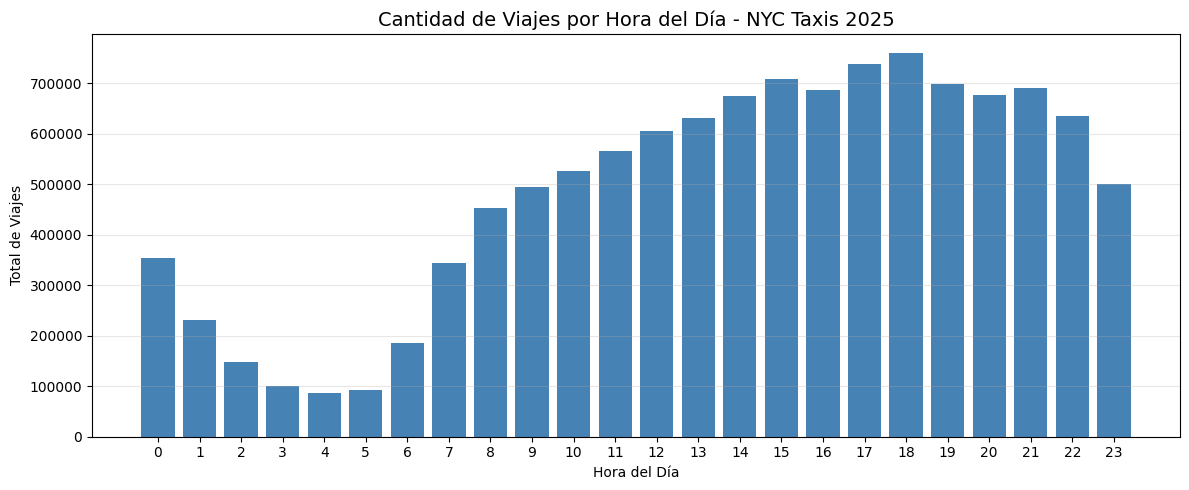

Gráfica 1 guardada


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(df_hora['pickup_hour'], df_hora['total_viajes'], color='steelblue')
plt.title('Cantidad de Viajes por Hora del Día - NYC Taxis 2025', fontsize=14)
plt.xlabel('Hora del Día')
plt.ylabel('Total de Viajes')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_demanda_hora.png', dpi=150)
plt.show()
print("Gráfica 1 guardada")

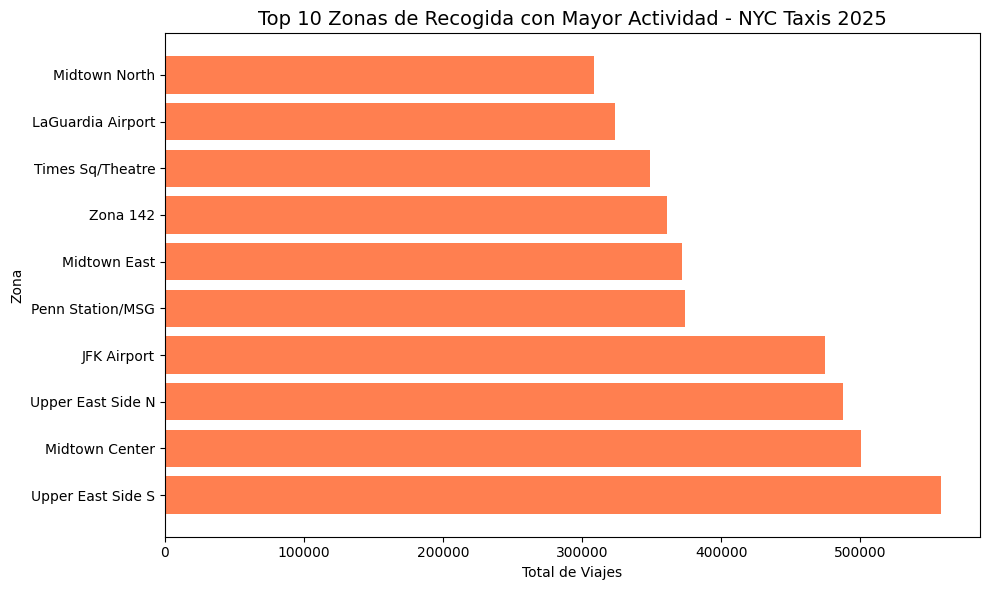

Gráfica 2 mejorada guardada


In [7]:
zone_names = {
    132: 'JFK Airport',
    138: 'LaGuardia Airport',
    161: 'Midtown Center',
    162: 'Midtown East',
    163: 'Midtown North',
    164: 'Midtown South',
    230: 'Times Sq/Theatre',
    236: 'Upper East Side N',
    237: 'Upper East Side S',
    161: 'Midtown Center',
    48:  'Clinton East',
    170: 'Murray Hill',
    186: 'Penn Station/MSG',
    234: 'Union Sq',
    107: 'Gramercy'
}

df_zona['zona_nombre'] = df_zona['PULocationID'].map(zone_names).fillna('Zona ' + df_zona['PULocationID'].astype(str))

plt.figure(figsize=(10, 6))
plt.barh(df_zona['zona_nombre'], df_zona['total_viajes'], color='coral')
plt.title('Top 10 Zonas de Recogida con Mayor Actividad - NYC Taxis 2025', fontsize=14)
plt.xlabel('Total de Viajes')
plt.ylabel('Zona')
plt.tight_layout()
plt.savefig('grafica_top_zonas.png', dpi=150)
plt.show()
print("Gráfica 2 mejorada guardada")

/tmp/ipykernel_15467/3919429157.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_propina, x='distance_range', y='propina_promedio', palette='viridis')


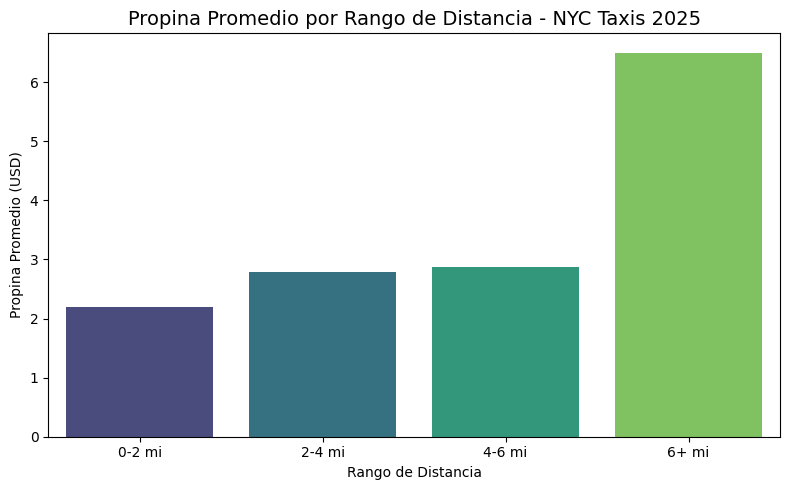

Gráfica 3 guardada


In [6]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=df_propina, x='distance_range', y='propina_promedio', palette='viridis')
plt.title('Propina Promedio por Rango de Distancia - NYC Taxis 2025', fontsize=14)
plt.xlabel('Rango de Distancia')
plt.ylabel('Propina Promedio (USD)')
plt.tight_layout()
plt.savefig('grafica_propina_dist.png', dpi=150)
plt.show()
print("Gráfica 3 guardada")

In [8]:
from google.cloud import storage

storage_client = storage.Client(project="nyctaxi-project-494018")
bucket = storage_client.bucket("proyecto-taxis-nyc-gamp")

archivos = [
    'grafica_demanda_hora.png',
    'grafica_top_zonas.png',
    'grafica_propina_dist.png'
]

for archivo in archivos:
    blob = bucket.blob(f"results/{archivo}")
    blob.upload_from_filename(archivo)
    print(f"✓ {archivo} subido a results/")

print("Todas las gráficas guardadas en el bucket")

✓ grafica_demanda_hora.png subido a results/
✓ grafica_top_zonas.png subido a results/
✓ grafica_propina_dist.png subido a results/
Todas las gráficas guardadas en el bucket


In [8]:
df_hora.to_csv('trips_by_hour.csv', index=False)
df_zona.to_csv('trips_by_zone.csv', index=False)
df_propina.to_csv('tip_by_distance.csv', index=False)

from google.cloud import storage
storage_client = storage.Client(project="nyctaxi-project-494018")
bucket = storage_client.bucket("proyecto-taxis-nyc-gamp")

for archivo in ['trips_by_hour.csv', 'trips_by_zone.csv', 'tip_by_distance.csv']:
    blob = bucket.blob(f"results/{archivo}")
    blob.upload_from_filename(archivo)
    print(f"✓ {archivo} subido")

✓ trips_by_hour.csv subido
✓ trips_by_zone.csv subido
✓ tip_by_distance.csv subido
